In [1]:
import re
from string import ascii_lowercase
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
import decoupler as dc
from magnitude import mg, new_mag, Magnitude

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import anndata2ri
import rpy2.rinterface_lib.callbacks as rcb
import rpy2.robjects as ro
from IPython import get_ipython

2025-08-20 16:05:36 | [INFO] cffi mode is CFFI_MODE.ANY
2025-08-20 16:05:36 | [INFO] R home found: /usr/lib/R
2025-08-20 16:05:36 | [INFO] R library path: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
2025-08-20 16:05:36 | [INFO] LD_LIBRARY_PATH: /usr/lib/R/lib:/usr/lib/x86_64-linux-gnu:/usr/lib/jvm/default-java/lib/server
2025-08-20 16:05:36 | [INFO] Default options to initialize R: rpy2, --quiet, --no-save
2025-08-20 16:05:36 | [INFO] Environment variable "PWD" redefined by R and overriding existing variable. Current: "/home/ubuntu", R: "/home/ubuntu/op3_v2/draft_notebooks"
2025-08-20 16:05:36 | [INFO] R is already initialized. No need to initialize.


In [4]:
pd.set_option('display.max_columns', 500)

In [5]:
new_mag('l', Magnitude(0.001, m=3))
new_mag('M', mg(1, 'mol/l'))

In [6]:
import matplotlib.pyplot as plt

In [7]:
STANDARD_ADATA_OBS_COLS = [
                 'plate', 
                 'well', 
                 'ngenes', 
                 'ncounts', 
                 'pcnt_mito',
                 'cell_type', 
                 'perturbagen',
                 'pert_type',
                 'is_control',
                 'pert_dose',
                 'pert_time',
                 'suspension_type',
                 'tissue',
                 'tissue_type', 
                 'disease',
                 'library',
                 'stimulation',
                 'guide',
                 'dataset',
                 'assay',
                 'development_stage',
                 'organism',
                 'sex',
                 'self_reported_ethnicity',
                 ]

CAT_COLS = [
                 'plate', 
                 'well', 
                 'cell_type', 
                 'perturbagen',
                 'pert_type',
                 'suspension_type',
                 'tissue',
                 'tissue_type', 
                 'disease',
                 'library',
                 'stimulation',
                 'guide',
                 'dataset',
                 'development_stage',
                 'organism',
                 'sex',
                 'self_reported_ethnicity'
                 ]


STANDARD_PADATA_OBS_COLS = [
                'sample_id', 
                'plate', 
                'well', 
                'cell_type',
                'perturbagen', 
                'pert_type', 
                'is_control', 
                'pert_dose', 
                'pert_dose_unit',
                'pert_time', 
                'pert_time_unit', 
                'suspension_type', 
                'tissue',
                'tissue_type', 
                'disease', 
                'library', 
                'stimulation', 
                'guide', 
                'dataset',
                'assay', 
                'development_stage', 
                'organism', 
                'sex',
                'self_reported_ethnicity', 
                'psbulk_cells', 
                'psbulk_counts'
                ]
    

STANDARD_VAR_COLS = ['symbol']

In [8]:
def split_val_units(s):
    r = "[-+]?[.]?[\d]+(?:,\d\d\d)*[\.]?\d*(?:[eE][-+]?\d+)?"
    try:
        val = float(re.findall(r, s)[0])
    except Exception as e:
        val = None
    try:
        units = re.split(r, s)[-1]
    except Exception as e:
        units = None
    return [val, units]

In [9]:
def standardize_doze(value, unit, default_unit='uM'):
    try:
        value_ = mg(value, unit).toval(default_unit)     
    except Exception as e:
        value_ = None
    return [value_, default_unit]

In [10]:
def standardize_obs_tahoe(adata):
    rename_cols = {'gene_count': 'ngenes', 
                   'tscp_count': 'ncounts',
                   'cell_line_ontology_id': 'cell_type',
                   'pert_compound': 'perturbagen',
                  }
    categories = {c: 'category' for c in CAT_COLS}
    wellnum2id_mapping = wellnum2id()
    adata.obs['well'] = adata.obs.index.to_series().str.split('_').str[0].astype(int).map(wellnum2id_mapping)
    #adata.obs['well'] = adata.obs['plate'] + '_' + adata.obs['well']
    adata.obs.rename(columns=rename_cols, inplace=True)
    adata.obs['is_control'] = adata.obs['perturbagen'] == 'DMSO_TF'
    adata.obs['library'] = None
    adata.obs['stimulation'] = None
    adata.obs['guide'] = None
    adata.obs['dataset'] = 'tahoe100'
    adata.obs = adata.obs[STANDARD_ADATA_OBS_COLS]
    adata.obs = adata.obs.astype(categories)
    return adata

In [11]:
def standardize_var_tahoe(adata):
    rename_cols = {'ensembl_gene_id': 'ensembl_id'}
    adata.var.rename(columns=rename_cols, inplace=True)
    adata.var.set_index('ensembl_id', inplace=True)
    return adata

In [12]:
def wellnum2id(nwells=96, ncols=12):
    mapping = {}
    for i in range(nwells):
        mapping[i + 1] = ascii_lowercase[i // ncols].upper() + str(i % ncols + 1)
    return mapping

In [13]:
def standardize_obs_sciplex(adata):
    rename_cols = {'n_genes': 'ngenes', 
                   'pct_counts_mt': 'pcnt_mito', 
                   'cell_type': 'cell_type_', 
                   'cell_line': 'cell_type',
                   'pert_compound': 'perturbagen'
                  }
    categories = {c: 'category' for c in CAT_COLS}

    map_clnames2ids = {'A549': 'CVCL_0023',
                       'K-562': 'CVCL_0004',
                       'MCF7': 'CVCL_0031',
                       }
    
    sc.pp.filter_cells(adata, min_genes=0)
    adata.var["mt"] = adata.var['symbol'].str.startswith("MT-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)
    adata.obs['pct_counts_mt'] /= 100
    adata.obs.rename(columns=rename_cols, inplace=True)
    adata.obs['cell_type'] = adata.obs['cell_type'].cat.rename_categories(map_clnames2ids)
    adata.obs['is_control'] = adata.obs['perturbagen'] == 'control'
    adata.obs['perturbagen'] = adata.obs['perturbagen'].cat.add_categories(['DMSO'])
    adata.obs.loc[adata.obs['perturbagen'] == 'control', 'perturbagen'] = 'DMSO'
    adata.obs['perturbagen'] = adata.obs['perturbagen'].cat.remove_categories(['control'])
    adata.obs['library'] = None
    adata.obs['stimulation'] = None
    adata.obs['guide'] = None
    adata.obs['dataset'] = 'srivatsan20_sciplex3'
    adata.obs = adata.obs[STANDARD_ADATA_OBS_COLS]
    adata.obs = adata.obs.astype(categories)
    return adata

In [14]:
def standardize_var_sciplex(adata):
    adata.var = adata.var[STANDARD_VAR_COLS]
    return adata

In [15]:
def standardize_padata(padata):
    if (padata is not None) and (padata.shape[0] != 0):
        padata.obs[['pert_dose', 'pert_dose_unit']] = padata.obs.apply(lambda x: split_val_units(x.pert_dose), axis=1, result_type='expand')
        padata.obs[['pert_dose', 'pert_dose_unit']] = padata.obs.apply(lambda x: standardize_doze(x.pert_dose, x.pert_dose_unit), axis=1, result_type='expand')
        padata.obs[['pert_time', 'pert_time_unit']] = padata.obs.apply(lambda x: split_val_units(x.pert_time), axis=1, result_type='expand')
        padata.obs[['psbulk_cells']] = padata.obs[['psbulk_cells']].astype(int)
        padata.obs[['psbulk_counts']] = padata.obs[['psbulk_counts']].astype(int)
        padata.obs.drop(columns=['pseudo_group'], inplace=True)
        padata.obs = padata.obs[STANDARD_PADATA_OBS_COLS]
    else:
        raise Exception
    return padata

In [16]:
def filter_by_nans(adata):
    is_outlier = adata.obs['well'].isna()
    return is_outlier

In [17]:
def filter_by_counts(adata, min_ngenes=250, min_ncounts=700, max_pcnt_mito=0.2):
    is_outlier = ~((adata.obs['ngenes'] >= min_ngenes)\
               & (adata.obs['ncounts'] >= min_ncounts)\
               & (adata.obs['pcnt_mito'] <= max_pcnt_mito))
    return is_outlier

In [18]:
def filter_by_humanMALAT1(adata, ignore_cell_lines=[], ens_id='ENSG00000251562', scaling=10000, threshold=3.5):
    is_malat1 = adata.var_names.str.startswith(ens_id)
    fraction_counts_malat1 = adata[:, is_malat1].X.toarray().sum(1)/adata.obs['ncounts'].values
    norm_malat1 = np.log1p(fraction_counts_malat1 * scaling)
    is_outlier = (norm_malat1 < threshold) & (~adata.obs['cell_type'].isin(ignore_cell_lines))
    return is_outlier

In [19]:
def filter_by_singlets(adata, nworkers=4, seed=42, singlet=1):
    X = adata.X.T
    r_script = f'''
    library(scDblFinder)
    library(BiocParallel)
    
    
    set.seed({seed})
    
    sce = scDblFinder(
        SingleCellExperiment(
            list(counts=X),
        ),
        BPPARAM = MulticoreParam(workers = {nworkers})
    )
    
    
    doublet_score = sce$scDblFinder.score
    doublet_class = sce$scDblFinder.class
    '''
    get_ipython().user_ns['X'] = X
    get_ipython().run_line_magic('load_ext', 'rpy2.ipython')
    anndata2ri.set_ipython_converter()
    get_ipython().run_cell_magic('R', '-i X -o doublet_score -o doublet_class', r_script)
    is_outlier = (doublet_class != singlet)
    return is_outlier

In [20]:
def filtering(adata,
             filter_counts=False,
             filter_nans=False,
             filter_malat1=False,
             filter_singlets=False):
    
    print(f'Initial adata size: {adata.shape}')
    is_outlier = np.zeros(adata.obs.shape[0], dtype=bool)
    if filter_counts:
        n_obs_prev = adata[~is_outlier].shape[0]
        is_outlier = filter_by_counts(adata)
        print(f'n_obs: {n_obs_prev} --> {adata[~is_outlier].shape[0]}')
    if filter_nans:
        n_obs_prev = adata[~is_outlier].shape[0]
        is_outlier = is_outlier | filter_by_nans(adata)
        print(f'n_obs: {n_obs_prev} --> {adata[~is_outlier].shape[0]}')
    if filter_malat1:
        n_obs_prev = adata[~is_outlier].shape[0]
        is_outlier_prev = is_outlier.copy()
        is_outlier = is_outlier | filter_by_humanMALAT1(adata)
        print(f'n_obs: {n_obs_prev} --> {adata[~is_outlier].shape[0]}')
    if filter_singlets:
        n_obs_prev = adata[~is_outlier].shape[0]
        is_outlier_prev = is_outlier.copy()
        is_outlier = is_outlier | filter_by_singlets(adata)
        print(f'n_obs: {n_obs_prev} --> {adata[~is_outlier].shape[0]}')
    print(f'Final adata size: {adata.shape}')
    return is_outlier

In [21]:
def set_groupby_fields(adata):
    groupby_fields = ['plate', 'well', 'perturbagen', 'cell_type']
    adata.obs['sample_id'] = adata.obs[groupby_fields].astype(str).apply(lambda row: '_'.join(row.values), axis=1, result_type='reduce')
    adata.obs['pseudo_group'] = 'all'
    return adata

## Tahoe

In [22]:
#path2adata = '../data/Tahoe/lamin_processed/plate1_filt_Vevo_Tahoe100M_WServicesFrom_ParseGigalab.h5ad'
path2adata = '../../data/Tahoe/lamin_processed/plate1_subsample.h5ad'
path2obs = '../../data/Tahoe/lamin_processed/plate1_obs.parquet'
path2var = '../../data/Tahoe/lamin_processed/var.parquet'

adata_tahoe = sc.read_h5ad(path2adata)
obs_tahoe = pd.read_parquet(path2obs)#.set_index("BARCODE_SUB_LIB_ID")
var_tahoe = pd.read_parquet(path2var)

In [23]:
if not adata_tahoe.obs.equals(obs_tahoe):
    col_index = adata_tahoe.obs.index.name
    if obs_tahoe.index.name != col_index:
        obs_tahoe.set_index(col_index, inplace=True)
    adata_tahoe.obs = adata_tahoe.obs.merge(obs_tahoe, how='left', on=col_index, suffixes=('_old', ''))
    
if not adata_tahoe.var.equals(var_tahoe):
    col_index = adata_tahoe.var.index.name
    if var_tahoe.index.name != col_index:
        var_tahoe.set_index(col_index, inplace=True)
    adata_tahoe.var = adata_tahoe.var.merge(var_tahoe, how='left', on=col_index, suffixes=('_old', ''))

In [24]:
adata_tahoe = standardize_obs_tahoe(adata_tahoe)

In [25]:
adata_tahoe = standardize_var_tahoe(adata_tahoe)

In [26]:
is_outlier_tahoe_1 = filtering(adata_tahoe,
                      filter_counts=True,
                      filter_nans=True,
                      filter_malat1=True,
                      filter_singlets=True)

Initial adata size: (5000, 62710)
n_obs: 5000 --> 4888
n_obs: 4888 --> 4888
n_obs: 4888 --> 4885


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

n_obs: 4885 --> 4473
Final adata size: (5000, 62710)


In [27]:
is_outlier_tahoe_2 = filtering(adata_tahoe,
                      filter_counts=True,
                      filter_nans=True,
                      filter_malat1=True,
                      filter_singlets=False)

Initial adata size: (5000, 62710)
n_obs: 5000 --> 4888
n_obs: 4888 --> 4888
n_obs: 4888 --> 4885
Final adata size: (5000, 62710)


In [28]:
filtering(adata_tahoe)

Initial adata size: (5000, 62710)
Final adata size: (5000, 62710)


array([False, False, False, ..., False, False, False], shape=(5000,))

In [29]:
adata_tahoe = set_groupby_fields(adata_tahoe)

## Pseudobulking

In [30]:
padata_full_tahoe = standardize_padata(dc.pp.pseudobulk(adata_tahoe[~filter_by_nans(adata_tahoe)],
                          sample_col='sample_id',
                          groups_col='pseudo_group',
                          ))

In [31]:
padata_1_tahoe = standardize_padata(dc.pp.pseudobulk(adata_tahoe[~is_outlier_tahoe_1],
                          sample_col='sample_id',
                          groups_col='pseudo_group',
                          ))

In [32]:
padata_2_tahoe = standardize_padata(dc.pp.pseudobulk(adata_tahoe[~is_outlier_tahoe_2],
                          sample_col='sample_id',
                          groups_col='pseudo_group',
                          ))

Text(0.5, 1.0, 'tahoe100_subset_psbulk_cells')

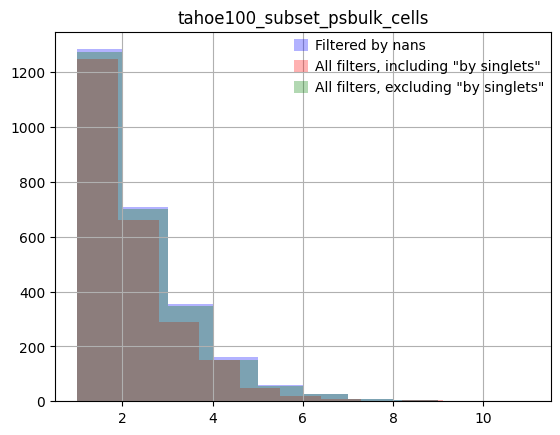

In [33]:
padata_full_tahoe.obs['psbulk_cells'].hist(bins=10, alpha=0.3, color='blue', label='Filtered by nans')
padata_1_tahoe.obs['psbulk_cells'].hist(bins=10, alpha=0.3, color='red', label='All filters, including "by singlets"')
padata_2_tahoe.obs['psbulk_cells'].hist(bins=10, alpha=0.3, color='green', label='All filters, excluding "by singlets"')

plt.legend()
plt.title('tahoe100_subset_psbulk_cells')

Text(0.5, 1.0, 'tahoe100_subset_psbulk_counts')

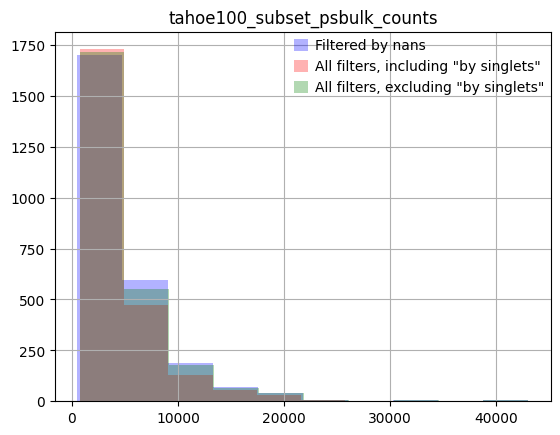

In [34]:
padata_full_tahoe.obs['psbulk_counts'].hist(bins=10, alpha=0.3, color='blue', label='Filtered by nans')
padata_1_tahoe.obs['psbulk_counts'].hist(bins=10, alpha=0.3, color='red', label='All filters, including "by singlets"')
padata_2_tahoe.obs['psbulk_counts'].hist(bins=10, alpha=0.3, color='green', label='All filters, excluding "by singlets"')

plt.legend()
plt.title('tahoe100_subset_psbulk_counts')

## Sciplex

In [37]:
path2adata = '../../data/Sciplex/raw/srivatsan20_sciplex3.h5ad'
path2obs = '../../data/Sciplex/raw/srivatsan20_sciplex3_obs.parquet'
path2var = '../../data/Sciplex/raw/srivatsan20_sciplex3_var.parquet'

adata_sci = sc.read_h5ad(path2adata)
obs_sci = pd.read_parquet(path2obs)
var_sci = pd.read_parquet(path2var)

In [38]:
#path2adata = '../data/Sciplex/lamin_processed/srivatsan20_sciplex3.h5ad'
#path2obs = '../data/Sciplex/lamin_processed/srivatsan20_sciplex3_obs.parquet'
#path2var = '../data/Sciplex/lamin_processed/srivatsan20_sciplex3_var.parquet'

#adata_sci = sc.read_h5ad('../data/Sciplex/full/raw/srivatsan20_sciplex3_subsample.h5ad')
#obs_sci = pd.read_parquet('../data/Sciplex/full/raw/srivatsan20_sciplex3_obs.parquet')
#var_sci = pd.read_parquet('../data/Sciplex/full/raw/srivatsan20_sciplex3_var.parquet')

In [39]:
adata_sci = standardize_obs_sciplex(adata_sci.copy())

In [40]:
adata_sci = standardize_var_sciplex(adata_sci.copy())

In [41]:
is_outlier_sci_1 = filtering(adata_sci,
                      filter_counts=True,
                      filter_nans=True,
                      filter_malat1=True,
                      filter_singlets=True)

Initial adata size: (799317, 58302)
n_obs: 799317 --> 425789
n_obs: 425789 --> 412454
n_obs: 412454 --> 294037
The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


dimnames(.) <- NULL translated to
dimnames(.) <- list(NULL,NULL)
dimnames(.) <- NULL translated to
dimnames(.) <- list(NULL,NULL)
dimnames(.) <- NULL translated to
dimnames(.) <- list(NULL,NULL)
Creating ~25000 artificial doublets...
Dimensional reduction
Evaluating kNN...
Training model...
iter=0, 369233 cells excluded from training.
iter=1, 233323 cells excluded from training.
iter=2, 233290 cells excluded from training.
Threshold found:0.999
227070 (28.4%) doublets called
In addition: Warning messages:
1: In .checkSCE(sce) :
  Some cells in `sce` have an extremely low read counts; note that these could trigger errors and might best be filtered out
2: In scDblFinder(SingleCellExperiment(list(counts = X), ), BPPARAM = MulticoreParam(workers = 4)) :
  You are trying to run scDblFinder on a very large number of cells. If these are from different captures, please specify this using the `samples` argument.TRUE
3: In asMethod(object) :
  sparse->dense coercion: allocating vector of size 3.

n_obs: 294037 --> 201959
Final adata size: (799317, 58302)


In [42]:
is_outlier_sci_2 = filtering(adata_sci,
                      filter_counts=True,
                      filter_nans=True,
                      filter_malat1=True,
                      filter_singlets=False)

Initial adata size: (799317, 58302)
n_obs: 799317 --> 425789
n_obs: 425789 --> 412454
n_obs: 412454 --> 294037
Final adata size: (799317, 58302)


In [43]:
adata_sci = set_groupby_fields(adata_sci)

In [44]:
adata_sci

AnnData object with n_obs × n_vars = 799317 × 58302
    obs: 'plate', 'well', 'ngenes', 'ncounts', 'pcnt_mito', 'cell_type', 'perturbagen', 'pert_type', 'is_control', 'pert_dose', 'pert_time', 'suspension_type', 'tissue', 'tissue_type', 'disease', 'library', 'stimulation', 'guide', 'dataset', 'assay', 'development_stage', 'organism', 'sex', 'self_reported_ethnicity', 'sample_id', 'pseudo_group'
    var: 'symbol'

### Pseudobulking

In [45]:
adata_sci[~is_outlier_sci_1].shape

(201959, 58302)

In [46]:
adata_sci[~is_outlier_sci_2].shape

(294037, 58302)

In [47]:
padata_full = standardize_padata(dc.pp.pseudobulk(adata_sci[~filter_by_nans(adata_sci)],
                          sample_col='sample_id',
                          groups_col='pseudo_group',
                          ))

In [48]:
padata_1 = standardize_padata(dc.pp.pseudobulk(adata_sci[~is_outlier_sci_1],
                          sample_col='sample_id',
                          groups_col='pseudo_group',
                          ))

In [49]:
padata_2 = standardize_padata(dc.pp.pseudobulk(adata_sci[~is_outlier_sci_2],
                          sample_col='sample_id',
                          groups_col='pseudo_group',
                          ))

Text(0.5, 1.0, 'sciplex_psbulk_cells')

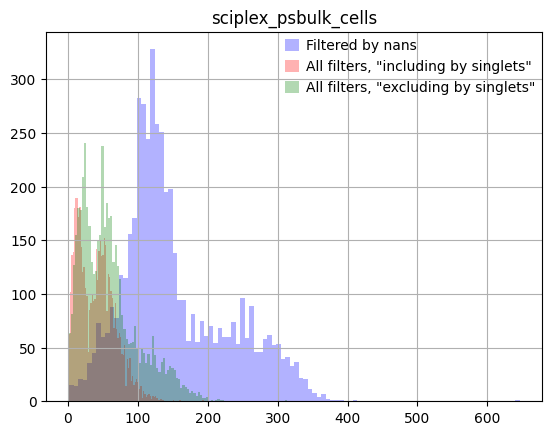

In [50]:
padata_full.obs['psbulk_cells'].hist(bins=100, alpha=0.3, color='blue', label='Filtered by nans')
padata_1.obs['psbulk_cells'].hist(bins=100, alpha=0.3, color='red', label='All filters, "including by singlets"')
padata_2.obs['psbulk_cells'].hist(bins=100, alpha=0.3, color='green', label='All filters, "excluding by singlets"')

plt.legend()
plt.title('sciplex_psbulk_cells')

Text(0.5, 1.0, 'sciplex_psbulk_counts')

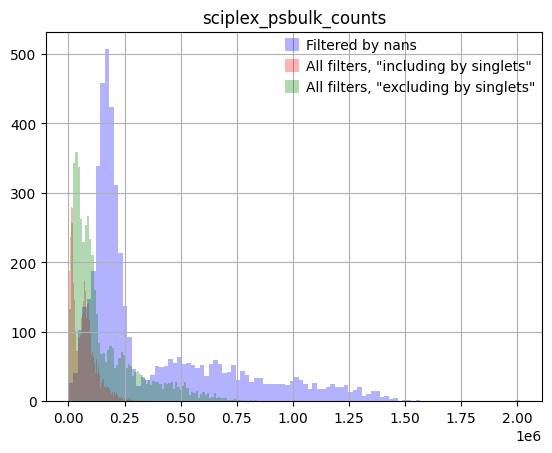

In [51]:
padata_full.obs['psbulk_counts'].hist(bins=100, alpha=0.3, color='blue', label='Filtered by nans')
padata_1.obs['psbulk_counts'].hist(bins=100, alpha=0.3, color='red', label='All filters, "including by singlets"')
padata_2.obs['psbulk_counts'].hist(bins=100, alpha=0.3, color='green', label='All filters, "excluding by singlets"')

plt.legend()
plt.title('sciplex_psbulk_counts')

## Pseudobulk format:

In [50]:
sc.read_h5ad('../../data/Tahoe/pseudobulk/subsample/tahoe.h5ad').obs

,plate,well,cell_type,perturbagen,pert_type,is_control,pert_dose,pert_dose_unit,pert_time,pert_time_unit,suspension_type,tissue,tissue_type,disease,library,stimulation,guide,dataset,assay,development_stage,organism,sex,self_reported_ethnicity,psbulk_cells,psbulk_counts,pubchem_cid
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,
plate12_A10_belinostat_CVCL_0069,1,A10,CVCL_0069,belinostat,compound,False,5.0,uM,24.0,h,cell,skin of body,cell culture,melanoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,60-year-old stage,human,male,European,2,9787,6918638.0
plate12_A10_belinostat_CVCL_0131,1,A10,CVCL_0131,belinostat,compound,False,5.0,uM,24.0,h,cell,brain,cell culture,glioblastoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,53-year-old stage,human,male,European,1,1170,6918638.0
plate12_A10_belinostat_CVCL_0152,1,A10,CVCL_0152,belinostat,compound,False,5.0,uM,24.0,h,cell,pancreas,cell culture,breast ductal adenocarcinoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,62-year-old stage,human,female,European,1,1411,6918638.0
plate12_A10_belinostat_CVCL_0293,1,A10,CVCL_0293,belinostat,compound,False,5.0,uM,24.0,h,cell,endometrium,cell culture,adenocarcinoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,71-year-old stage,human,female,European,1,4871,6918638.0
plate12_A10_belinostat_CVCL_0320,1,A10,CVCL_0320,belinostat,compound,False,5.0,uM,24.0,h,cell,colon,cell culture,adenocarcinoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,44-year-old stage,human,female,European,1,3040,6918638.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
plate6_H9_Clonidine (hydrochloride)_CVCL_1693,14,H9,CVCL_1693,Clonidine (hydrochloride),compound,False,5.0,uM,24.0,h,cell,lung,cell culture,small cell carcinoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,54-year-old stage,human,male,European,1,3298,20179.0
plate6_H9_Clonidine (hydrochloride)_CVCL_1717,14,H9,CVCL_1717,Clonidine (hydrochloride),compound,False,5.0,uM,24.0,h,cell,colon,cell culture,adenocarcinoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,53-year-old stage,human,female,European,2,5639,20179.0
plate6_H9_Clonidine (hydrochloride)_CVCL_1724,14,H9,CVCL_1724,Clonidine (hydrochloride),compound,False,5.0,uM,24.0,h,cell,colon,cell culture,adenocarcinoma,NaN,NaN,NaN,tahoe100,Parse Evercode Whole Transcriptome v3,83-year-old stage,human,female,European,1,2866,20179.0


In [51]:
sc.read_h5ad('../../data/Sciplex/pseudobulk/srivatsan20_sciplex3.h5ad').obs

,plate,well,cell_type,perturbagen,pert_type,is_control,pert_dose,pert_dose_unit,pert_time,pert_time_unit,suspension_type,tissue,tissue_type,disease,library,stimulation,guide,dataset,assay,development_stage,organism,sex,self_reported_ethnicity,psbulk_cells,psbulk_counts,pubchem_cid
sample_id,,,,,,,,,,,,,,,,,,,,,,,,,,
plate10_plate4_A10_tazemetostat_CVCL_0023,plate10,plate4_A10,CVCL_0023,tazemetostat,compound,False,0.01,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,7,8687,66558664.0
plate10_plate4_A11_JNJ-7706621_CVCL_0023,plate10,plate4_A11,CVCL_0023,JNJ-7706621,compound,False,0.01,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,12,12506,5330790.0
plate10_plate4_A12_ofloxacin_CVCL_0023,plate10,plate4_A12,CVCL_0023,ofloxacin,compound,False,0.01,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,9,15805,4583.0
plate10_plate4_A1_SRT2104_CVCL_0023,plate10,plate4_A1,CVCL_0023,SRT2104,compound,False,0.10,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,14,18855,25108829.0
plate10_plate4_A2_belinostat_CVCL_0023,plate10,plate4_A2,CVCL_0023,belinostat,compound,False,0.10,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,25,33161,6918638.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
plate9_plate3_H5_PHA-680632_CVCL_0023,plate9,plate3_H5,CVCL_0023,PHA-680632,compound,False,10.00,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,5,7444,11249084.0
plate9_plate3_H6_PCI-34051_CVCL_0023,plate9,plate3_H6,CVCL_0023,PCI-34051,compound,False,10.00,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,7,10609,24753719.0
plate9_plate3_H7_ITSA-1_CVCL_0023,plate9,plate3_H7,CVCL_0023,ITSA-1,compound,False,1.00,uM,24.0,h,nucleus,lung,cell culture,lung adenocarcinoma,NaN,NaN,NaN,srivatsan20_sciplex3,sci-Plex,unknown,human,male,European,10,18439,771910.0


## Malat1 distributions

In [299]:
def plot_humanMALAT1(adata, title, color, ens_id='ENSG00000251562', scaling=10000, threshold=3.5):
    is_malat1 = adata.var_names.str.startswith(ens_id)
    fraction_counts_malat1 = adata[:, is_malat1].X.toarray().sum(1)/adata.obs['ncounts'].values
    norm_malat1 = np.log1p(fraction_counts_malat1 * scaling)
    
    plt.title(title)
    plt.hist(norm_malat1, alpha=0.5, color=color)
    plt.axvline(x = threshold, color = 'r')
    plt.xlabel('normalized malat1 counts')
    plt.xlim([0, 10])
    plt.show()
    #is_outlier = norm_malat1 < threshold
    #return is_outlier

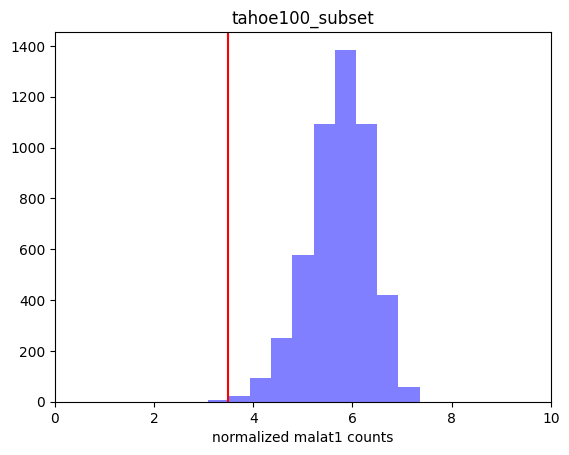

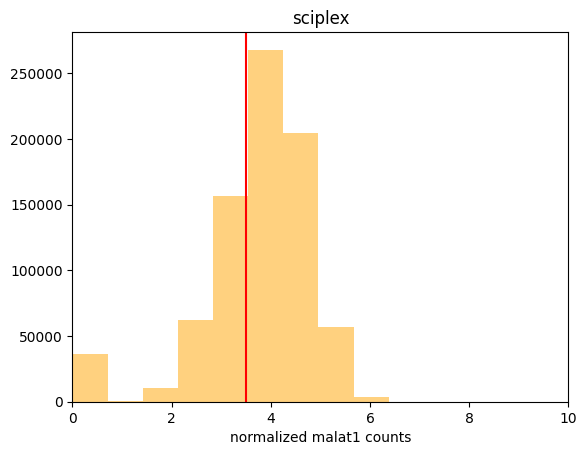

In [300]:
plot_humanMALAT1(adata_tahoe, 'tahoe100_subset', 'blue')
plot_humanMALAT1(adata_sci, 'sciplex', 'orange')